# Task 10: NLP Feedback Analysis
## Internship Project | NLP & Sentiment Classification
---
**Objectives:**
- Create a synthetic feedback dataset (`coretech_feedback.csv`)
- Clean and preprocess text data
- Analyze sentiment distribution
- Find most common words
- Build a sentiment classification model using CountVectorizer + Naive Bayes / Logistic Regression


In [1]:
# ── Step 1: Import Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

print("✅ All libraries imported successfully!")
print(f"pandas  : {pd.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")


✅ All libraries imported successfully!
pandas  : 3.0.2
sklearn : 1.8.0


In [2]:
# ── Step 2: Create coretech_feedback.csv Dataset ──────────────────────────────
data = {
    'Feedback_ID': range(1, 36),
    'Client_Name': [
        'Alice Johnson','Bob Smith','Carol White','David Lee','Eva Martinez',
        'Frank Brown','Grace Wilson','Henry Taylor','Isla Anderson','Jake Thomas',
        'Karen Jackson','Liam Harris','Mia Martin','Noah Garcia','Olivia Moore',
        'Peter Clark','Quinn Lewis','Rachel Walker','Sam Hall','Tina Allen',
        'Uma Young','Victor King','Wendy Scott','Xander Green','Yara Baker',
        'Zoe Adams','Aaron Nelson','Bella Carter','Carlos Mitchell','Diana Perez',
        'Ethan Roberts','Fiona Turner','George Phillips','Hannah Campbell','Ivan Parker'
    ],
    'Service': [
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity',
        'Cloud Hosting','Tech Support','Software Dev','Data Analytics','Cybersecurity'
    ],
    'Feedback_Text': [
        'The cloud service was absolutely fantastic! Fast, reliable, and easy to use.',
        'Support was okay but the response time could be improved a little.',
        'Excellent development work! The team delivered beyond expectations.',
        'The analytics dashboard is very helpful and easy to navigate.',
        'Security setup was decent but I expected more detailed documentation.',
        'Service was terrible. The server went down multiple times this month!',
        'Tech support team was extremely helpful and resolved my issue quickly.',
        'Software delivery was delayed and the quality was below average.',
        'Great insights from the analytics team. Very satisfied with the results.',
        'Cybersecurity audit was thorough and very professional.',
        'Cloud uptime has been flawless. No complaints whatsoever.',
        'Support ticket took 3 days to resolve. Very disappointing experience.',
        'The software is buggy and crashes frequently. Needs major improvements.',
        'Average analytics service. Nothing exceptional but gets the job done.',
        'Impressed by the security protocols implemented by the team.',
        'Cloud storage solution exceeded my expectations! Highly recommend.',
        'Tech support was rude and unhelpful. Will not use this service again.',
        'Good software solution but documentation could be much better.',
        'Data reports are insightful and well-presented. Great job team!',
        'Security service is reliable and the team is knowledgeable.',
        'Worst cloud experience ever. Data migration was a complete disaster.',
        'Support team responded quickly and solved the issue on first call.',
        'Software project was completed on time and within the budget. Impressed!',
        'Analytics tool is slow and produces inaccurate results sometimes.',
        'Top-notch cybersecurity team. Feel confident in our data protection.',
        'Cloud service keeps disconnecting. Very frustrating and unreliable.',
        'Outstanding support experience! Would definitely recommend to others.',
        'Development team was responsive and professional throughout the project.',
        'Data analytics service is mediocre. Not worth the premium price.',
        'Satisfied with the security assessment. Detailed and comprehensive report.',
        'Cloud service is cost-effective and highly scalable. Very happy!',
        'Tech support was slow and the issue remains unresolved even now.',
        'Average software quality. Met basic requirements but nothing more.',
        'Excellent analytics! Helped us make better business decisions quickly.',
        'Great cybersecurity team. Identified vulnerabilities we never knew existed.'
    ],
    'Rating': [
        5,3,5,4,3,1,5,2,5,5,
        5,2,1,3,4,5,1,3,5,4,
        1,5,5,2,5,1,5,4,3,4,
        5,2,3,5,5
    ],
    'Sentiment': [
        'Positive','Neutral','Positive','Positive','Neutral','Negative','Positive','Negative','Positive','Positive',
        'Positive','Negative','Negative','Neutral','Positive','Positive','Negative','Neutral','Positive','Positive',
        'Negative','Positive','Positive','Negative','Positive','Negative','Positive','Positive','Neutral','Positive',
        'Positive','Negative','Neutral','Positive','Positive'
    ]
}

df = pd.DataFrame(data)
df.to_csv('coretech_feedback.csv', index=False)

print("✅ Dataset created and saved as 'coretech_feedback.csv'")
print(f"Shape: {df.shape}")
print(f"\nColumn Names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


✅ Dataset created and saved as 'coretech_feedback.csv'
Shape: (35, 6)

Column Names: ['Feedback_ID', 'Client_Name', 'Service', 'Feedback_Text', 'Rating', 'Sentiment']

First 5 rows:


,Feedback_ID,Client_Name,Service,Feedback_Text,Rating,Sentiment
0,1,Alice Johnson,Cloud Hosting,The cloud service was absolutely fantastic! Fa...,5,Positive
1,2,Bob Smith,Tech Support,Support was okay but the response time could b...,3,Neutral
2,3,Carol White,Software Dev,Excellent development work! The team delivered...,5,Positive
3,4,David Lee,Data Analytics,The analytics dashboard is very helpful and ea...,4,Positive
4,5,Eva Martinez,Cybersecurity,Security setup was decent but I expected more ...,3,Neutral


In [3]:
# ── Step 3: Exploratory Data Analysis (EDA) ───────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Records   : {df.shape[0]}")
print(f"Total Columns   : {df.shape[1]}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nSentiment Distribution:")
print(df['Sentiment'].value_counts())
print(f"\nService Distribution:")
print(df['Service'].value_counts())
print(f"\nRating Statistics:")
print(df['Rating'].describe())


DATASET OVERVIEW
Total Records   : 35
Total Columns   : 6

Data Types:
Feedback_ID      int64
Client_Name        str
Service            str
Feedback_Text      str
Rating           int64
Sentiment          str
dtype: object

Missing Values:
Feedback_ID      0
Client_Name      0
Service          0
Feedback_Text    0
Rating           0
Sentiment        0
dtype: int64

Sentiment Distribution:
Sentiment
Positive    20
Negative     9
Neutral      6
Name: count, dtype: int64

Service Distribution:
Service
Cloud Hosting     7
Tech Support      7
Software Dev      7
Data Analytics    7
Cybersecurity     7
Name: count, dtype: int64

Rating Statistics:
count    35.000000
mean      3.600000
std       1.499019
min       1.000000
25%       2.500000
50%       4.000000
75%       5.000000
max       5.000000
Name: Rating, dtype: float64


In [4]:
# ── Step 4: Text Cleaning ─────────────────────────────────────────────────────
def clean_text(text):
    """Clean and preprocess feedback text."""
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)           # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra whitespace
    return text

# Apply cleaning
df['Cleaned_Text'] = df['Feedback_Text'].apply(clean_text)

# Show before/after
print("✅ Text Cleaning Complete!")
print("\nSample Before vs After Cleaning:")
print("-" * 60)
for i in range(3):
    print(f"Original : {df['Feedback_Text'].iloc[i]}")
    print(f"Cleaned  : {df['Cleaned_Text'].iloc[i]}")
    print()


✅ Text Cleaning Complete!

Sample Before vs After Cleaning:
------------------------------------------------------------
Original : The cloud service was absolutely fantastic! Fast, reliable, and easy to use.
Cleaned  : the cloud service was absolutely fantastic fast reliable and easy to use

Original : Support was okay but the response time could be improved a little.
Cleaned  : support was okay but the response time could be improved a little

Original : Excellent development work! The team delivered beyond expectations.
Cleaned  : excellent development work the team delivered beyond expectations



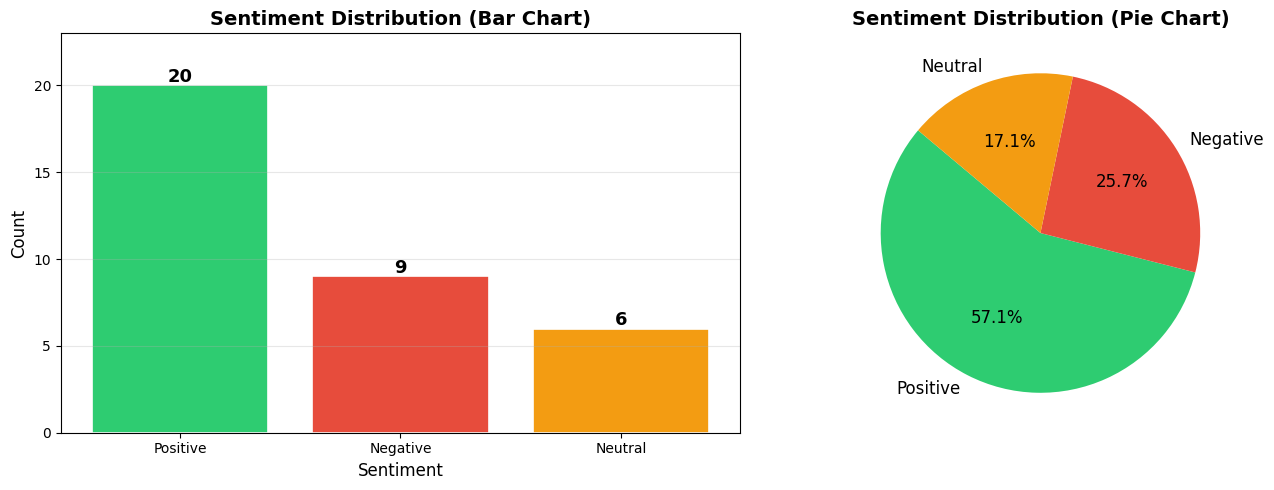

✅ Sentiment distribution chart saved!


In [5]:
# ── Step 5: Sentiment Distribution Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar Chart
sentiment_counts = df['Sentiment'].value_counts()
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bar_colors = [colors[s] for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors,
            edgecolor='white', linewidth=1.2)
axes[0].set_title('Sentiment Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, max(sentiment_counts.values) + 3)
axes[0].grid(axis='y', alpha=0.3)

# ── Pie Chart
pie_colors = [colors[s] for s in sentiment_counts.index]
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=pie_colors,
            startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sentiment distribution chart saved!")


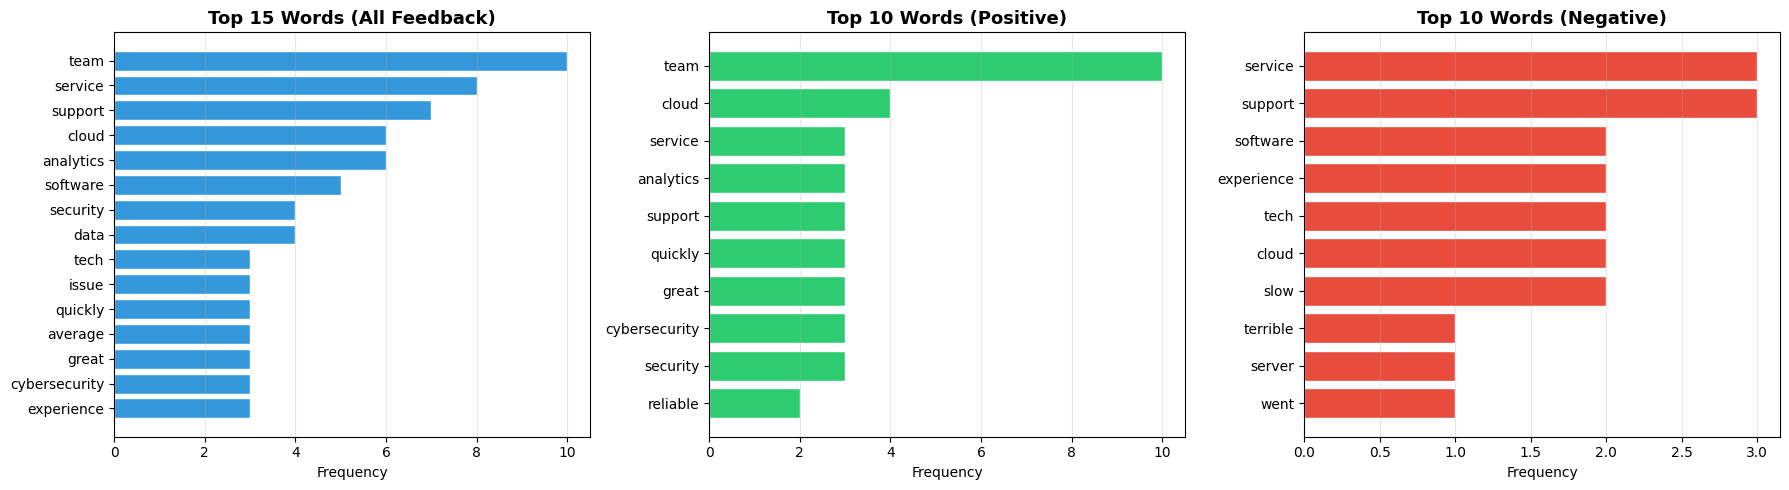

✅ Most common words chart saved!

Top 10 Overall Words: ['team', 'service', 'support', 'cloud', 'analytics', 'software', 'security', 'data', 'tech', 'issue']


In [6]:
# ── Step 6: Most Common Words Analysis ────────────────────────────────────────
# Custom stopwords
stopwords = set([
    'the','and','was','is','a','an','to','of','in','it','be','for',
    'this','that','are','with','my','i','very','was','were','has',
    'have','not','but','on','at','by','we','our','their','more','been',
    'could','would','would','will','from','or'
])

def get_words(text_series):
    all_words = []
    for text in text_series:
        words = text.split()
        words = [w for w in words if w not in stopwords and len(w) > 2]
        all_words.extend(words)
    return all_words

all_words    = get_words(df['Cleaned_Text'])
pos_words    = get_words(df[df['Sentiment']=='Positive']['Cleaned_Text'])
neg_words    = get_words(df[df['Sentiment']=='Negative']['Cleaned_Text'])

top_all = Counter(all_words).most_common(15)
top_pos = Counter(pos_words).most_common(10)
top_neg = Counter(neg_words).most_common(10)

# ── Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_words(ax, word_counts, title, color):
    words, counts = zip(*word_counts)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

plot_words(axes[0], top_all, 'Top 15 Words (All Feedback)', '#3498db')
plot_words(axes[1], top_pos, 'Top 10 Words (Positive)', '#2ecc71')
plot_words(axes[2], top_neg, 'Top 10 Words (Negative)', '#e74c3c')

plt.tight_layout()
plt.savefig('common_words.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Most common words chart saved!")
print(f"\nTop 10 Overall Words: {[w for w,c in top_all[:10]]}")


In [7]:
# ── Step 7: Sentiment Classification Model ────────────────────────────────────
# Prepare features and labels
X = df['Cleaned_Text']
y = df['Sentiment']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())


Training samples : 28
Testing samples  : 7

Class distribution in training set:
Sentiment
Positive    16
Negative     7
Neutral      5
Name: count, dtype: int64


In [8]:
# ── Step 7a: Model 1 — CountVectorizer + Multinomial Naive Bayes ──────────────
cv = CountVectorizer(ngram_range=(1,2), max_features=500)
X_train_cv = cv.fit_transform(X_train)
X_test_cv  = cv.transform(X_test)

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_cv, y_train)
y_pred_nb = nb_model.predict(X_test_cv)

print("=" * 55)
print("  Model 1: CountVectorizer + Multinomial Naive Bayes")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))


  Model 1: CountVectorizer + Multinomial Naive Bayes
Accuracy : 0.7143

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       1.00      1.00      1.00         1
    Positive       0.67      1.00      0.80         4

    accuracy                           0.71         7
   macro avg       0.56      0.67      0.60         7
weighted avg       0.52      0.71      0.60         7



In [9]:
# ── Step 7b: Model 2 — TfidfVectorizer + Logistic Regression ─────────────────
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=500)
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_tf, y_train)
y_pred_lr = lr_model.predict(X_test_tf)

print("=" * 55)
print("  Model 2: TfidfVectorizer + Logistic Regression")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))


  Model 2: TfidfVectorizer + Logistic Regression
Accuracy : 0.5714

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
     Neutral       0.00      0.00      0.00         1
    Positive       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.19      0.33      0.24         7
weighted avg       0.33      0.57      0.42         7



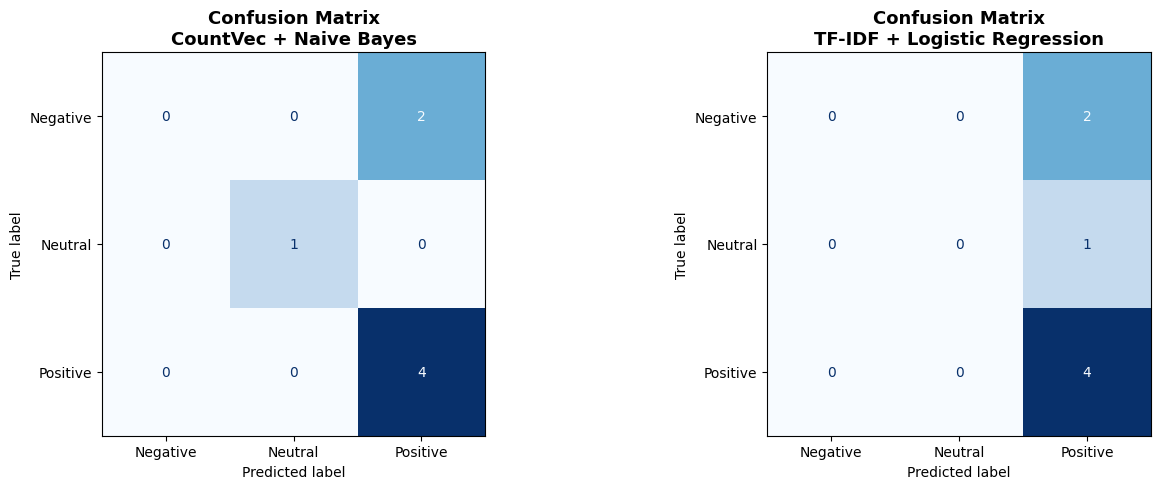

✅ Confusion matrices saved!


In [10]:
# ── Step 8: Confusion Matrix Visualization ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Negative', 'Neutral', 'Positive']

for ax, y_pred, title in zip(
    axes,
    [y_pred_nb, y_pred_lr],
    ['CountVec + Naive Bayes', 'TF-IDF + Logistic Regression']
):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{title}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")


In [11]:
# ── Step 9: Model Comparison Summary ─────────────────────────────────────────
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)

comparison_df = pd.DataFrame({
    'Model'      : ['CountVec + Naive Bayes', 'TF-IDF + Logistic Regression'],
    'Vectorizer' : ['CountVectorizer', 'TfidfVectorizer'],
    'Classifier' : ['MultinomialNB', 'LogisticRegression'],
    'Accuracy'   : [round(acc_nb, 4), round(acc_lr, 4)]
})

print("=" * 55)
print("         MODEL COMPARISON SUMMARY")
print("=" * 55)
print(comparison_df.to_string(index=False))
print()
best = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
print(f"🏆 Best Model: {best}")


         MODEL COMPARISON SUMMARY
                       Model      Vectorizer         Classifier  Accuracy
      CountVec + Naive Bayes CountVectorizer      MultinomialNB    0.7143
TF-IDF + Logistic Regression TfidfVectorizer LogisticRegression    0.5714

🏆 Best Model: CountVec + Naive Bayes


In [12]:
# ── Step 10: Predict Sentiment on New Feedback ────────────────────────────────
new_feedback = [
    "The service is outstanding and the team is very professional!",
    "Extremely disappointed with the slow support and poor quality.",
    "Service is average, nothing special but works fine for basic needs."
]

cleaned_new = [clean_text(t) for t in new_feedback]
new_vec = tfidf.transform(cleaned_new)
predictions = lr_model.predict(new_vec)

print("🔍 Sentiment Prediction on New Feedback")
print("=" * 65)
for fb, pred in zip(new_feedback, predictions):
    emoji = {'Positive':'✅','Neutral':'⚪','Negative':'❌'}[pred]
    print(f"{emoji} [{pred:8s}] {fb}")


🔍 Sentiment Prediction on New Feedback
✅ [Positive] The service is outstanding and the team is very professional!
✅ [Positive] Extremely disappointed with the slow support and poor quality.
✅ [Positive] Service is average, nothing special but works fine for basic needs.


## ✅ Task 10 Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Dataset created with 35 feedback records | ✅ Done |
| 2 | Columns: Feedback_ID, Client_Name, Service, Feedback_Text, Rating, Sentiment | ✅ Done |
| 3 | Text cleaning (lowercase, remove punctuation, strip whitespace) | ✅ Done |
| 4 | Sentiment distribution analysis + charts | ✅ Done |
| 5 | Most common words (overall, positive, negative) | ✅ Done |
| 6 | Model 1: CountVectorizer + Multinomial Naive Bayes | ✅ Done |
| 7 | Model 2: TfidfVectorizer + Logistic Regression | ✅ Done |
| 8 | Confusion matrix visualization for both models | ✅ Done |
| 9 | Model comparison & best model identified | ✅ Done |
| 10 | Prediction on unseen feedback samples | ✅ Done |

> **Dataset saved as:** `coretech_feedback.csv`  
> **Charts saved:** `sentiment_distribution.png`, `common_words.png`, `confusion_matrices.png`
